# VoxBind - Generated Ligand Visualization

Inspects the output of `sample.py` for one pocket - 3D pose, 2D depictions and
per-molecule metrics - then summarises metrics across all sampled pockets.

### How to use
1. Run **section 0 (Setup)** once.
2. In **section 1**, set `SAMPLE_DIR` and `TARGET_IDX` for the pocket to inspect.
3. Run **sections 2-4** to view that pocket; **section 5** aggregates them all.

### Notes
- Reads `sample.py` output directly (pocket PDB, GT ligand SDF, `samples.sdf`).
  Section 5's Vina docking charts additionally read each target's cached
  `metrics.json` (written by the webapp / `00_dashboard.ipynb`).
- Chemical metrics (QED / SA / LogP / Lipinski) come from TargetDiff's
  `get_chem`; SA is the normalised score (0-1, higher = easier to synthesise).
- The 3D viewer uses Plotly; the 2D grid uses RDKit's Cairo drawer.

In [16]:
# Section 0 - Setup: imports and helper functions (run once).
import json
import math
import re
import sys
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from PIL import Image
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem.Draw import rdMolDraw2D

RDLogger.DisableLog("rdApp.*")
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})


# -- locate VoxBind and the sibling TargetDIff, independent of kernel cwd -----
HERE = Path.cwd().resolve()
VOXBIND = next((p for p in [HERE, *HERE.parents] if p.name == "VoxBind"), None)
if VOXBIND is None:
    raise RuntimeError(f"Could not locate VoxBind project root from cwd={HERE}")
TARGETDIFF = VOXBIND.parent / "TargetDIff"   # case-sensitive
if not TARGETDIFF.exists():
    raise FileNotFoundError(f"TargetDIff not found at {TARGETDIFF}")
for _p in (str(VOXBIND), str(TARGETDIFF)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from utils.evaluation.scoring_func import get_chem  # noqa: E402  (from TargetDIff)

# 3D-viewer palette and per-element colours / sizes.
palette = px.colors.qualitative.Plotly + px.colors.qualitative.Safe
ELEM_COLOR = {"C": "gray", "N": "cornflowerblue", "O": "tomato",
              "S": "gold", "F": "limegreen", "Cl": "lime", "P": "orange"}
ELEM_SIZE = {"C": 3.5, "N": 3.5, "O": 3.2, "S": 4.5,
             "F": 2.8, "Cl": 4.0, "P": 4.0}


# -- structure loading -------------------------------------------------------
def parse_pocket_pdb(pdb_path):
    """Heavy-atom coordinates and element symbols from a pocket PDB."""
    coords, elems = [], []
    for line in open(pdb_path):
        if not (line.startswith("ATOM") or line.startswith("HETATM")):
            continue
        try:
            x, y, z = float(line[30:38]), float(line[38:46]), float(line[46:54])
        except ValueError:
            continue
        elem = line[76:78].strip() if len(line) > 76 else ""
        if not elem:
            elem = re.sub(r"[^A-Za-z]", "", line[12:16]).strip()[:2].capitalize()
        if elem in ("H", "D"):
            continue
        coords.append([x, y, z])
        elems.append(elem)
    return np.array(coords, dtype=float), elems


def mol_coords(mol):
    """(N, 3) conformer coordinates of an RDKit mol."""
    conf = mol.GetConformer()
    return np.array([conf.GetAtomPosition(i) for i in range(mol.GetNumAtoms())])


def mol_elems(mol):
    """Element symbols of an RDKit mol's atoms."""
    return [a.GetSymbol() for a in mol.GetAtoms()]


def load_gt(td):
    """The GT (reference) ligand of a target_* dir, or None if absent."""
    gt_sdf = next((p for p in td.glob("*.sdf") if p.name != "samples.sdf"), None)
    if gt_sdf is None:
        return None
    return next(iter(Chem.SDMolSupplier(str(gt_sdf), removeHs=True, sanitize=True)),
                None)


def load_target(td):
    """Load one target_* dir: pocket coords/elems, GT ligand, generated mols."""
    pdb = next(iter(sorted(td.glob("*_pocket10.pdb"))), None)
    if pdb is None:
        raise FileNotFoundError(f"No pocket PDB in {td}")
    poc_xyz, poc_el = parse_pocket_pdb(str(pdb))
    gen, samples_sdf = [], td / "samples.sdf"
    if samples_sdf.exists():
        gen = [m for m in Chem.SDMolSupplier(str(samples_sdf), removeHs=False,
                                             sanitize=True) if m is not None]
    return poc_xyz, poc_el, load_gt(td), gen, pdb.stem


def target_docking(td):
    """Mean Vina affinities over a target's samples and its reference ligand.

    Read from metrics.json (written by the webapp / 00_dashboard). Returns the
    keys present - vina_score/min/dock and ref_vina_* - or {} when no docking.
    """
    mp = td / "metrics.json"
    if not mp.exists():
        return {}
    try:
        data = json.loads(mp.read_text())
    except (json.JSONDecodeError, OSError):
        return {}
    keymap = {"score_only": "vina_score", "minimize": "vina_min", "dock": "vina_dock"}
    out = {}
    for src, dst in keymap.items():
        vals = [s["vina"][src] for s in data.get("samples", [])
                if isinstance(s.get("vina"), dict) and "error" not in s["vina"]
                and isinstance(s["vina"].get(src), (int, float))]
        if vals:
            out[dst] = float(np.mean(vals))
    ref = data.get("reference")
    rv = ref.get("vina") if isinstance(ref, dict) else None
    if isinstance(rv, dict) and "error" not in rv:
        for src, dst in keymap.items():
            if isinstance(rv.get(src), (int, float)):
                out["ref_" + dst] = float(rv[src])
    return out


# -- metrics and 2D depiction ------------------------------------------------
def mol_to_pil(mol, size=(280, 220)):
    """Render an RDKit mol to a PIL image."""
    drawer = rdMolDraw2D.MolDraw2DCairo(*size)
    drawer.drawOptions().addStereoAnnotation = True
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    return Image.open(BytesIO(drawer.GetDrawingText()))


def compute_metrics(mol):
    """QED / SA / LogP / Lipinski / heavy-atom count for one mol (via get_chem)."""
    c = get_chem(mol)
    return {"QED": round(c["qed"], 3), "SA": round(c["sa"], 2),
            "LogP": round(c["logp"], 2), "Lipinski": int(c["lipinski"]),
            "HAtoms": mol.GetNumHeavyAtoms()}


def tanimoto_diversity(mols):
    """1 - mean pairwise Tanimoto similarity (NaN for fewer than 2 mols)."""
    if len(mols) < 2:
        return float("nan")
    fps = [Chem.RDKFingerprint(m) for m in mols]
    sims = [DataStructs.TanimotoSimilarity(fps[i], fps[j])
            for i in range(len(fps)) for j in range(i + 1, len(fps))]
    return 1.0 - float(np.mean(sims))


print("helpers ready: parse_pocket_pdb, mol_coords, mol_elems, load_gt,")
print("               load_target, target_docking, mol_to_pil, compute_metrics,")
print("               tanimoto_diversity")

helpers ready: parse_pocket_pdb, mol_coords, mol_elems, load_gt,
               load_target, target_docking, mol_to_pil, compute_metrics,
               tanimoto_diversity


## 1. Config

`SAMPLE_DIR` should contain `target_*/` subdirectories with a `samples.sdf` and the pocket PDB / GT ligand SDF (the format produced by `sample.py`).

In [17]:
# Section 1 - choose the sample directory and target.
SAMPLE_DIR = (
    Path("/home/shpark/prj-denovo/VoxBind/voxbind/exps")
	/ "260514_voxbind_100ep340"
 	/ "samples"
  	/ "res_ep7999_val"
)
TARGET_IDX = 0

SAMPLE_DIR = SAMPLE_DIR.resolve()
target_dirs = sorted(SAMPLE_DIR.glob("target_*"))
print(f"sample dir    : {SAMPLE_DIR}")
print(f"targets found : {len(target_dirs)}")
for _td in target_dirs:
    _sdf = _td / "samples.sdf"
    _n = len(list(Chem.SDMolSupplier(str(_sdf), sanitize=False))) if _sdf.exists() else 0
    print(f"  {_td.name}  -  {_n} generated mols")

sample dir    : /home/shpark/prj-denovo/VoxBind/voxbind/exps/260514_voxbind_100ep340/samples/res_ep7999_val
targets found : 10
  target_00  -  10 generated mols
  target_01  -  10 generated mols
  target_02  -  10 generated mols
  target_03  -  10 generated mols
  target_04  -  10 generated mols
  target_05  -  10 generated mols
  target_06  -  10 generated mols
  target_07  -  10 generated mols
  target_08  -  10 generated mols
  target_09  -  10 generated mols


## 2. Load pocket, GT ligand, generated samples

In [18]:
# Section 2 - load the selected target's pocket, GT ligand and samples.
td = target_dirs[TARGET_IDX]
poc_coords, poc_elems, gt_mol, gen_mols, pocket_name = load_target(td)

print(f"target    : {td.name}")
print(f"pocket    : {pocket_name}  ({len(poc_coords)} heavy atoms)")
print(f"GT ligand : {'found' if gt_mol else 'not found'}",
      f"({gt_mol.GetNumAtoms()} atoms)" if gt_mol else "")
print(f"generated : {len(gen_mols)} molecules")

target    : target_00
pocket    : FA11_HUMAN_388_625_0__1xx9_A_rec_4d76_j1j_lig_tt_min_0_pocket10  (301 heavy atoms)
GT ligand : found (35 atoms)
generated : 10 molecules


## 3. Interactive 3D viewer

Pocket (translucent grey) + GT ligand (large, outlined) + generated ligands (one trace per molecule).

In [19]:
# Section 3 - Plotly 3D viewer: pocket + GT ligand + generated ligands.
traces = []

# pocket - semi-transparent markers
for elem in sorted(set(poc_elems)):
    xyz = poc_coords[[i for i, e in enumerate(poc_elems) if e == elem]]
    traces.append(go.Scatter3d(
        x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2], mode="markers",
        marker=dict(size=ELEM_SIZE.get(elem, 3),
                    color=ELEM_COLOR.get(elem, "white"), opacity=0.20),
        name=f"Pocket {elem}", legendgroup="pocket",
    ))

# GT ligand - large diamonds with a white outline
if gt_mol is not None:
    gt_xyz, gt_elems = mol_coords(gt_mol), mol_elems(gt_mol)
    for elem in sorted(set(gt_elems)):
        xyz = gt_xyz[[i for i, e in enumerate(gt_elems) if e == elem]]
        traces.append(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2], mode="markers",
            marker=dict(size=ELEM_SIZE.get(elem, 3.5) * 1.8,
                        color=ELEM_COLOR.get(elem, "purple"), opacity=0.95,
                        symbol="diamond", line=dict(width=1.5, color="white")),
            name=f"GT {elem}", legendgroup="gt",
        ))

# generated ligands - one trace per molecule
for i, mol in enumerate(gen_mols):
    xyz = mol_coords(mol)
    smi = Chem.MolToSmiles(mol)
    traces.append(go.Scatter3d(
        x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2], mode="markers",
        marker=dict(size=6, color=palette[i % len(palette)], opacity=0.85,
                    line=dict(width=0.6, color="white")),
        name=f"Gen {i}: {smi[:34]}{'...' if len(smi) > 34 else ''}",
        legendgroup=f"gen_{i}", text=mol_elems(mol),
        hovertemplate="%{text}<br>(%{x:.2f}, %{y:.2f}, %{z:.2f})<extra>%{fullData.name}</extra>",
    ))

fig = go.Figure(traces)
fig.update_layout(
    title=f"{td.name}  -  pocket {len(poc_coords)} atoms, GT, {len(gen_mols)} generated",
    scene=dict(xaxis_title="X (Å)", yaxis_title="Y (Å)",
               zaxis_title="Z (Å)", aspectmode="data"),
    width=900, height=650,
    legend=dict(itemsizing="constant", groupclick="toggleitem"),
    margin=dict(l=0, r=0, t=50, b=0),
)
fig.show()

## 4. 2D molecule grid + per-molecule metrics

RDKit 2D depictions with QED / SA / LogP / Lipinski / heavy-atom count.

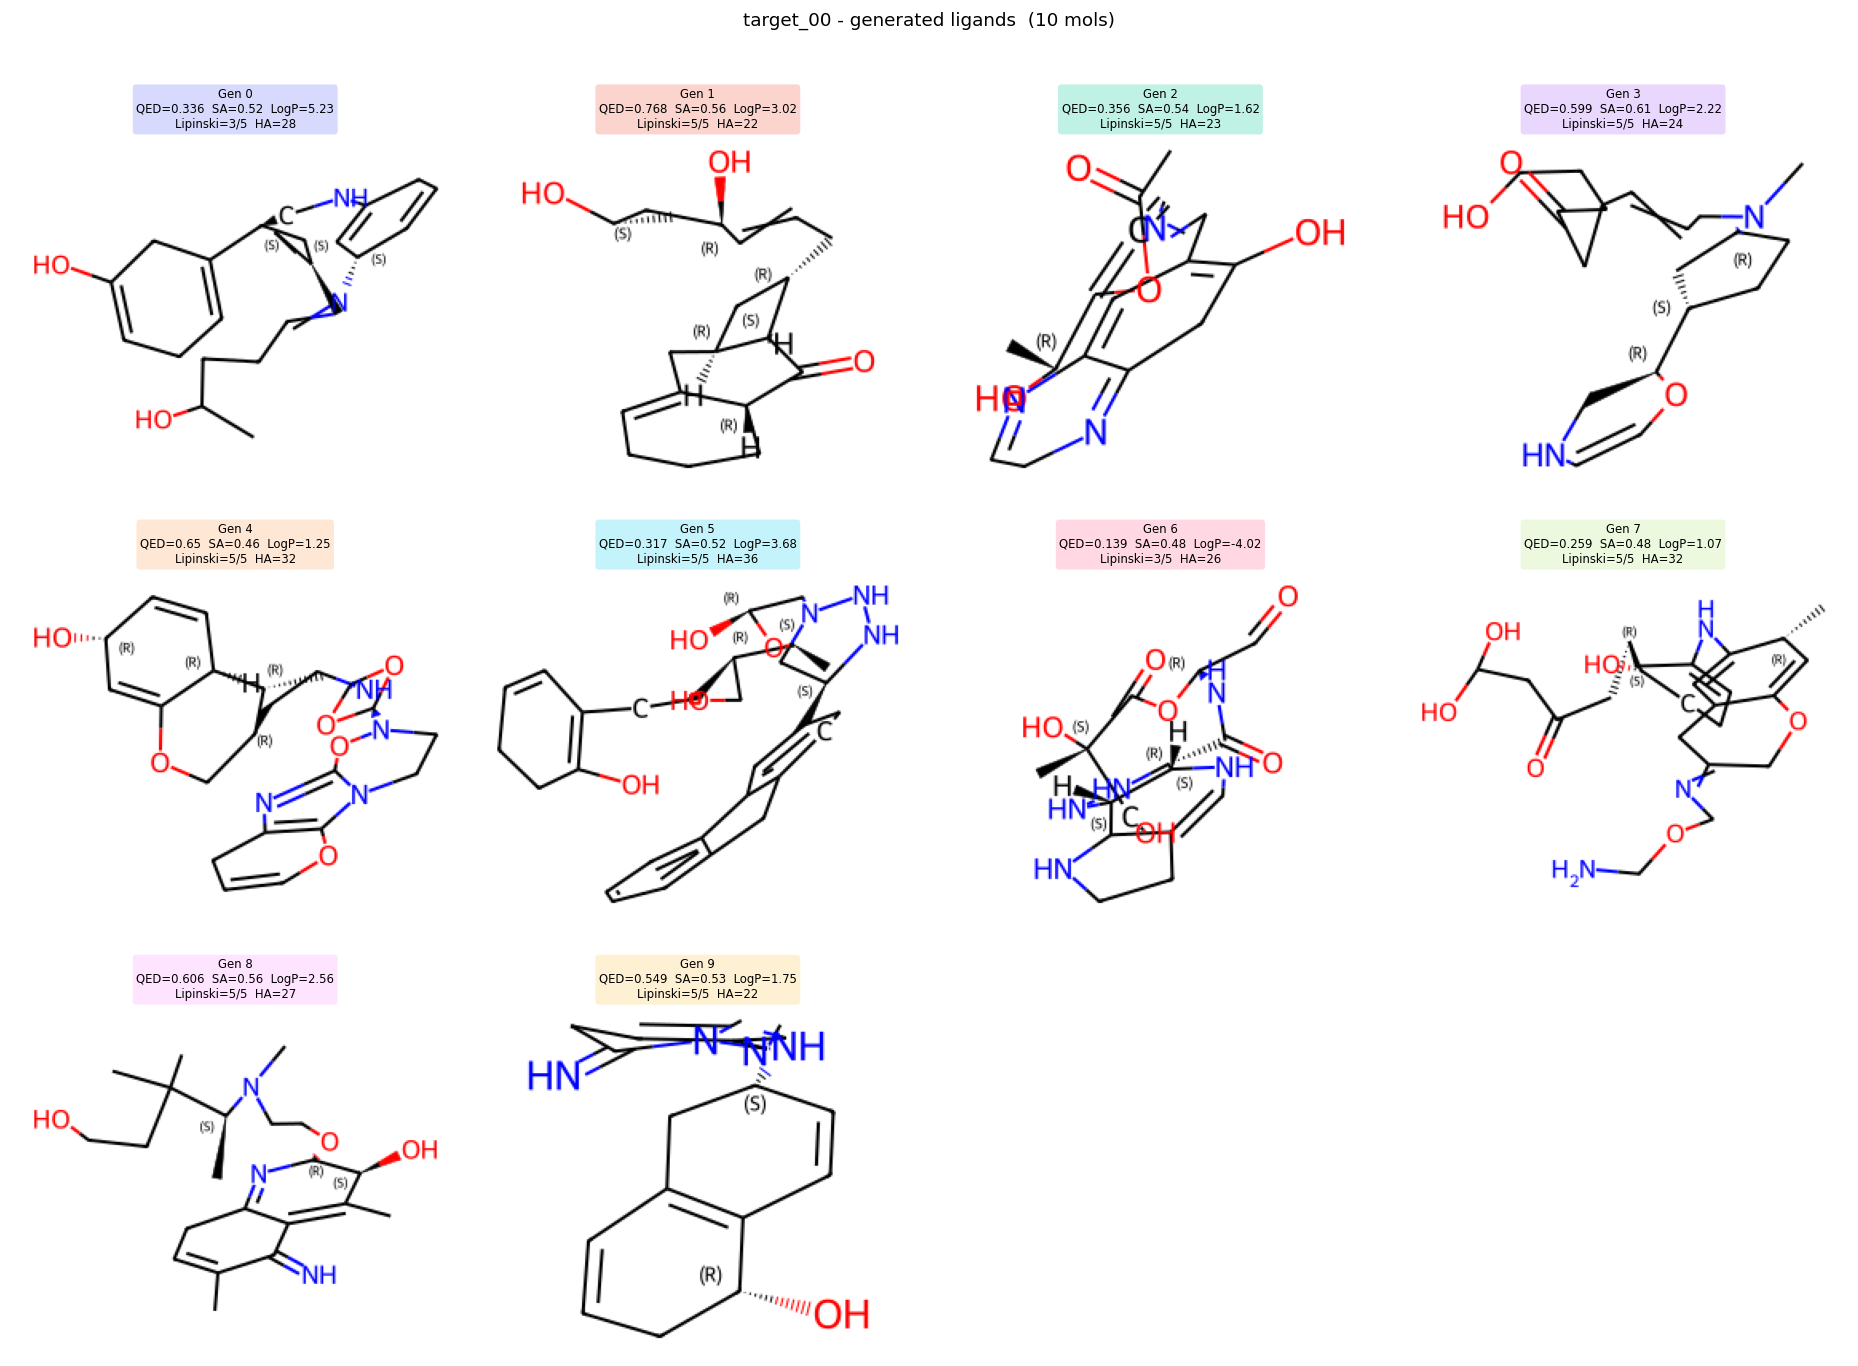

In [20]:
# Section 4 - 2D depiction grid with per-molecule metrics.
n_cols = 4
n_rows = math.ceil(len(gen_mols) / n_cols)
mol_w, mol_h = 280, 220

fig_grid, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * mol_w / 72, n_rows * (mol_h + 58) / 72),
)
axes = np.array(axes).reshape(-1)

for i, mol in enumerate(gen_mols):
    axes[i].imshow(mol_to_pil(mol, size=(mol_w, mol_h)))
    axes[i].axis("off")
    m = compute_metrics(mol)
    axes[i].set_title(
        f"Gen {i}\n"
        f"QED={m['QED']}  SA={m['SA']}  LogP={m['LogP']}\n"
        f"Lipinski={m['Lipinski']}/5  HA={m['HAtoms']}",
        fontsize=7, pad=3,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor=palette[i % len(palette)], alpha=0.25, linewidth=0),
    )

for j in range(len(gen_mols), len(axes)):
    axes[j].set_visible(False)

fig_grid.suptitle(f"{td.name} - generated ligands  ({len(gen_mols)} mols)",
                   fontsize=11, y=1.01)
fig_grid.tight_layout()
plt.show()

## 5. Aggregate metrics across all targets

Per-target metrics and their mean, per-target bar plots (with the reference
ligand drawn as a horizontal line), Vina docking bar plots when available, and
a QED-vs-SA scatter.

In [21]:
# Section 5 - per-target metrics (generated, reference ligand, Vina docking).
rows = []
for _td in target_dirs:
    sdf_path = _td / "samples.sdf"
    if not sdf_path.exists():
        continue
    raw = list(Chem.SDMolSupplier(str(sdf_path), sanitize=False))
    valid = [m for m in Chem.SDMolSupplier(str(sdf_path), sanitize=True)
             if m is not None and "." not in Chem.MolToSmiles(m)]
    if not valid:
        rows.append({"target": _td.name, "n_total": len(raw), "n_valid": 0})
        continue
    smiles = [Chem.MolToSmiles(m) for m in valid]
    chems = [get_chem(m) for m in valid]
    row = {
        "target": _td.name,
        "n_total": len(raw),
        "n_valid": len(valid),
        "validity": len(valid) / len(raw),
        "uniqueness": len(set(smiles)) / len(valid),
        "diversity": tanimoto_diversity(valid),
        "qed": np.mean([c["qed"] for c in chems]),
        "sa": np.mean([c["sa"] for c in chems]),
        "logp": np.mean([c["logp"] for c in chems]),
        "lipinski": np.mean([c["lipinski"] for c in chems]),
    }
    gt = load_gt(_td)                 # reference-ligand chemical metrics
    if gt is not None:
        gc = get_chem(gt)
        row["ref_qed"], row["ref_sa"] = gc["qed"], gc["sa"]
    row.update(target_docking(_td))   # mean Vina + reference Vina, if computed
    rows.append(row)

df = pd.DataFrame([r for r in rows if r.get("n_valid", 0) > 0]).set_index("target")
_metric_cols = ["validity", "uniqueness", "diversity", "qed", "sa", "logp", "lipinski"]
print(f"targets evaluated : {len(df)} / {len(rows)}")
print()
print(df[_metric_cols].mean().round(4).to_string())

targets evaluated : 10 / 10

validity      1.0000
uniqueness    1.0000
diversity     0.7271
qed           0.5267
sa            0.5774
logp          2.1404
lipinski      4.7800


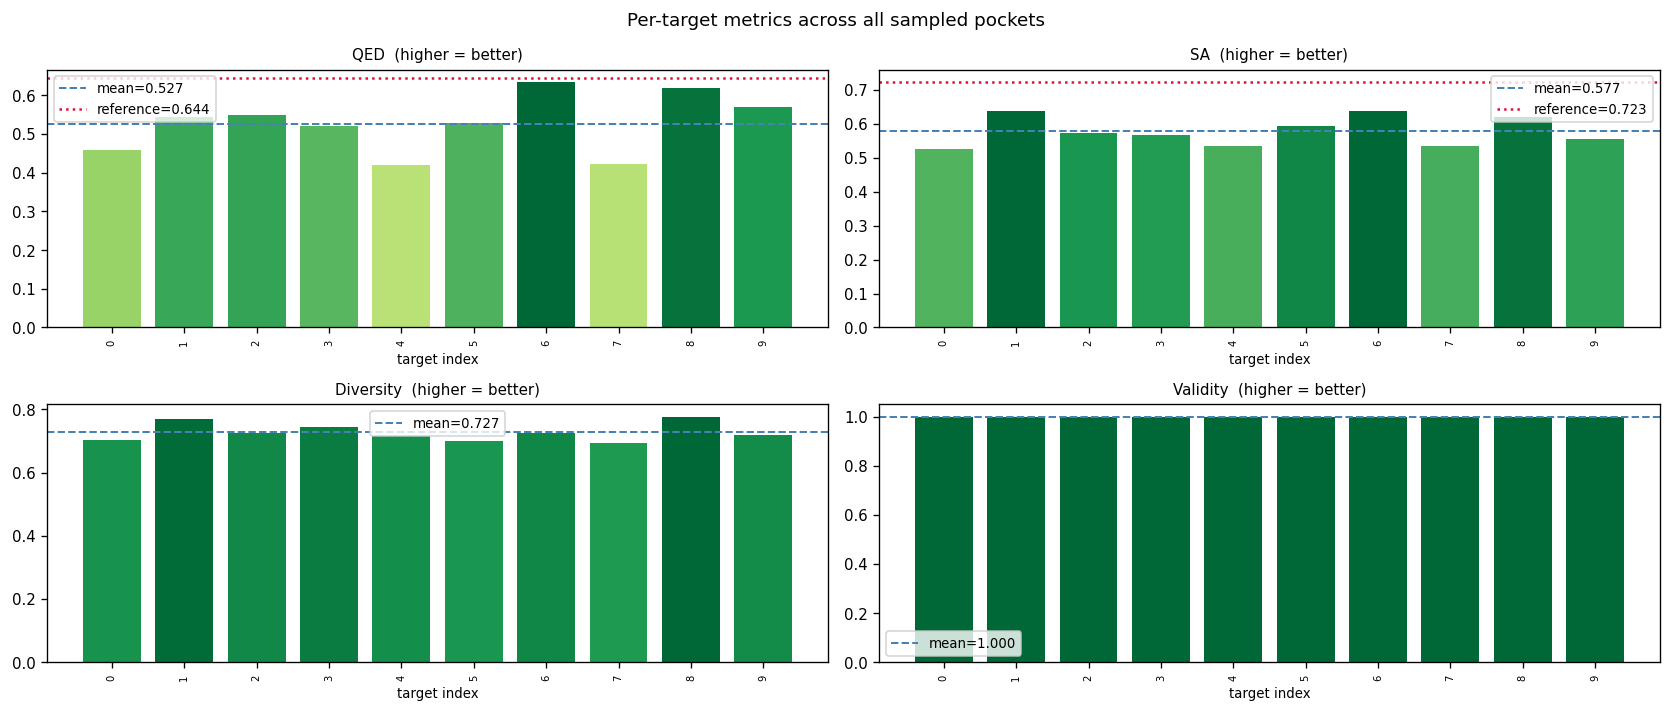

In [22]:
# Section 5 - per-target metric bar plots (with reference-ligand mean line).
plot_keys = [("qed", "QED", "ref_qed"), ("sa", "SA", "ref_sa"),
             ("diversity", "Diversity", None), ("validity", "Validity", None)]

fig_bar, axes = plt.subplots(2, 2, figsize=(14, 6))
for ax, (col, label, ref_col) in zip(axes.flatten(), plot_keys):
    vals = df[col].dropna()
    ax.bar(range(len(vals)), vals.values,
           color=plt.cm.RdYlGn(vals.values / max(vals.max(), 1e-9)),
           edgecolor="none")
    ax.axhline(vals.mean(), color="steelblue", ls="--", lw=1.2,
               label=f"mean={vals.mean():.3f}")
    # reference ligand - only QED / SA are defined for a single molecule
    if ref_col and ref_col in df.columns and df[ref_col].notna().any():
        ref_mean = df[ref_col].mean()
        ax.axhline(ref_mean, color="crimson", ls=":", lw=1.5,
                   label=f"reference={ref_mean:.3f}")
    ax.set_title(f"{label}  (higher = better)", fontsize=9)
    ax.set_xlabel("target index", fontsize=8)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(range(len(vals)), fontsize=6, rotation=90)
    ax.legend(fontsize=8)

fig_bar.suptitle("Per-target metrics across all sampled pockets", fontsize=11)
fig_bar.tight_layout()
plt.show()

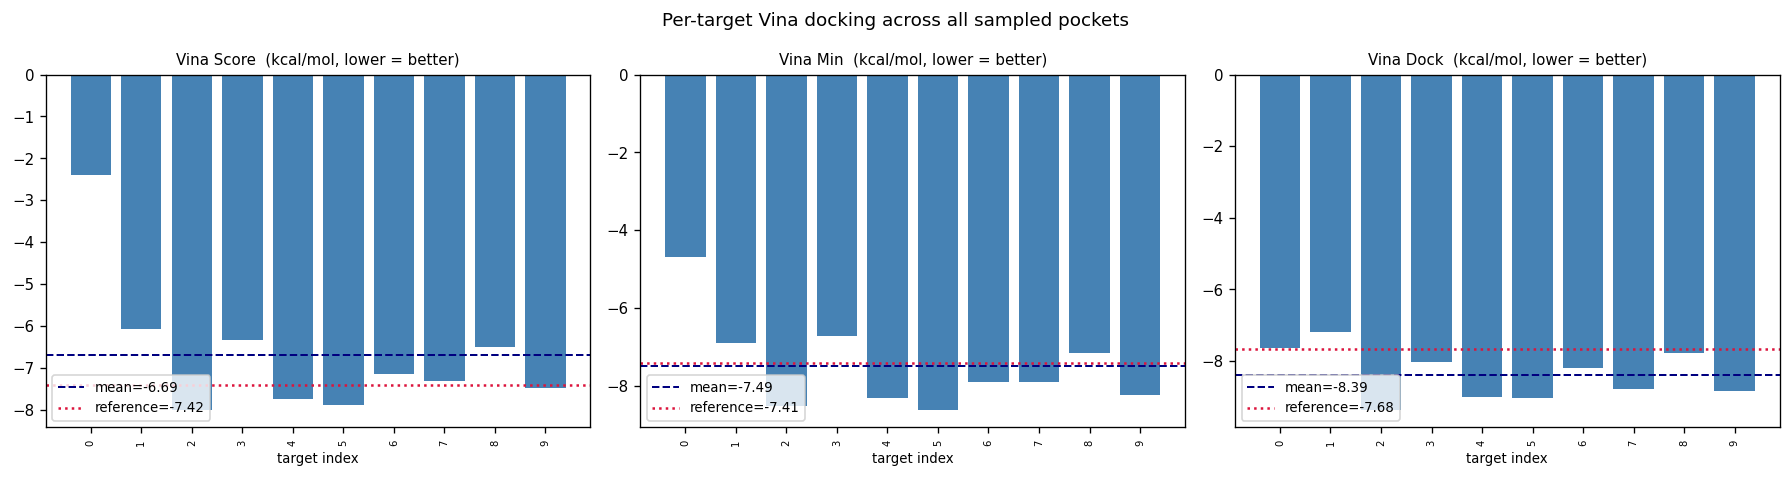

In [23]:
# Section 5 - per-target Vina docking bar plots (if docking was computed).
dock_keys = [("vina_score", "Vina Score"), ("vina_min", "Vina Min"),
             ("vina_dock", "Vina Dock")]
dock_cols = [k for k, _ in dock_keys if k in df.columns and df[k].notna().any()]

if not dock_cols:
    print("Vina docking not available - compute it via the webapp "
          "(notebook/webapp/app.py), then re-run.")
else:
    fig_dock, axes = plt.subplots(1, len(dock_cols),
                                  figsize=(5 * len(dock_cols), 4), squeeze=False)
    for ax, col in zip(axes.flatten(), dock_cols):
        label = dict(dock_keys)[col]
        series = df[col]
        ax.bar(range(len(series)), series.values, color="steelblue",
               edgecolor="none")
        ax.axhline(series.mean(), color="navy", ls="--", lw=1.2,
                   label=f"mean={series.mean():.2f}")
        ref_col = "ref_" + col
        if ref_col in df.columns and df[ref_col].notna().any():
            ref_mean = df[ref_col].mean()
            ax.axhline(ref_mean, color="crimson", ls=":", lw=1.5,
                       label=f"reference={ref_mean:.2f}")
        ax.set_title(f"{label}  (kcal/mol, lower = better)", fontsize=9)
        ax.set_xlabel("target index", fontsize=8)
        ax.set_xticks(range(len(series)))
        ax.set_xticklabels(range(len(series)), fontsize=6, rotation=90)
        ax.legend(fontsize=8)
    fig_dock.suptitle("Per-target Vina docking across all sampled pockets",
                      fontsize=11)
    fig_dock.tight_layout()
    plt.show()

In [24]:
# Section 5 - QED vs SA scatter, sized by sample count, coloured by diversity.
fig_scatter = go.Figure(go.Scatter(
    x=df["sa"], y=df["qed"], mode="markers+text",
    text=df.index, textposition="top center", textfont=dict(size=7),
    marker=dict(size=df["n_valid"] * 3, color=df["diversity"],
                colorscale="Viridis", showscale=True,
                colorbar=dict(title="Diversity", thickness=12, len=0.7),
                opacity=0.8, line=dict(width=0.5, color="white")),
    hovertemplate=("<b>%{text}</b><br>SA=%{x:.2f}  QED=%{y:.3f}<br>"
                   "Diversity=%{marker.color:.3f}<extra></extra>"),
))
fig_scatter.update_layout(
    title="QED vs SA  -  bubble size = valid mols, colour = diversity",
    xaxis_title="SA  (higher = easier to synthesise)",
    yaxis_title="QED  (higher = more drug-like)",
    width=800, height=520,
)
fig_scatter.show()